# Caselaw Query Selectivity Check

This notebook computes query-filter selectivity against the base metadata and reports:
- min / mean(average) / median / max
- Quantiles
- Histogram and bucketed distribution
- Per-query selectivity details

In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_dir = Path('.')
query_path = data_dir / 'caselaw_query_single_vector_filters_100.jsonl'
base_path = data_dir / 'caselaw_base_single_vector_metadata.jsonl'

print('query file:', query_path.resolve())
print('base file :', base_path.resolve())
print('query exists:', query_path.exists())
print('base exists :', base_path.exists())

query file: /scratch1/zhan4404/dataset/caselaw/caselaw_query_single_vector_filters_100.jsonl
base file : /scratch1/zhan4404/dataset/caselaw/caselaw_base_single_vector_metadata.jsonl
query exists: True
base exists : True


In [3]:
# Read query filters
queries = []
with query_path.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        obj = json.loads(line)
        queries.append({
            'query_id': int(obj.get('query_id', len(queries))),
            'filter': obj.get('filter', {})
        })

print('num queries:', len(queries))
print('example filter:', json.dumps(queries[0]['filter'], ensure_ascii=False)[:300], '...')

num queries: 89227
example filter: {"$and": [{"date_filed": {"$gte": 734700}}, {"date_filed": {"$lte": 736161}}]} ...


In [4]:
# Recursively parse Mongo-like filters into pandas boolean masks
def _all_true(df):
    return pd.Series(True, index=df.index)

def _all_false(df):
    return pd.Series(False, index=df.index)

def build_mask(df, expr):
    if expr is None:
        return _all_true(df)

    if isinstance(expr, list):
        if not expr:
            return _all_true(df)
        m = _all_true(df)
        for sub in expr:
            m = m & build_mask(df, sub)
        return m

    if not isinstance(expr, dict):
        raise ValueError(f'Unsupported filter node type: {type(expr)}')

    if '$and' in expr:
        parts = expr['$and']
        if not parts:
            return _all_true(df)
        m = _all_true(df)
        for sub in parts:
            m = m & build_mask(df, sub)
        return m

    if '$or' in expr:
        parts = expr['$or']
        if not parts:
            return _all_false(df)
        m = _all_false(df)
        for sub in parts:
            m = m | build_mask(df, sub)
        return m

    if '$nor' in expr:
        return ~build_mask(df, {'$or': expr['$nor']})

    if '$not' in expr:
        return ~build_mask(df, expr['$not'])

    m = _all_true(df)
    for field, cond in expr.items():
        if field.startswith('$'):
            raise ValueError(f'Unsupported top-level operator: {field}')

        if field not in df.columns:
            m = m & _all_false(df)
            continue

        col = df[field]

        if isinstance(cond, dict):
            field_mask = _all_true(df)
            for op, val in cond.items():
                if op == '$eq':
                    field_mask = field_mask & (col == val)
                elif op == '$ne':
                    field_mask = field_mask & (col != val)
                elif op == '$gt':
                    field_mask = field_mask & (col > val)
                elif op == '$gte':
                    field_mask = field_mask & (col >= val)
                elif op == '$lt':
                    field_mask = field_mask & (col < val)
                elif op == '$lte':
                    field_mask = field_mask & (col <= val)
                elif op == '$in':
                    field_mask = field_mask & col.isin(val)
                elif op == '$nin':
                    field_mask = field_mask & (~col.isin(val))
                else:
                    raise ValueError(f'Unsupported operator: {op}')
            m = m & field_mask
        else:
            m = m & (col == cond)

    return m

# Quick sanity check on one query
_ = queries[0]['filter']
print('filter parser ready')

filter parser ready


In [5]:
# Efficient version: first build date_filed indexes grouped by labels, then count per query
from collections import defaultdict

chunk_size = 200_000
total_base = 0

global_date_parts = []
dates_by_full_name_parts = defaultdict(list)
dates_by_type_parts = defaultdict(list)
dates_by_juris_parts = defaultdict(list)
dates_by_type_juris_parts = defaultdict(list)

reader = pd.read_json(base_path, lines=True, chunksize=chunk_size)
for chunk_id, df in enumerate(reader, start=1):
    total_base += len(df)

    date_arr = df["date_filed"].to_numpy(dtype=np.int32, copy=False)
    full_name_arr = df["court_full_name"].to_numpy(copy=False)
    type_arr = df["court_type"].to_numpy(copy=False)
    juris_arr = df["court_jurisdiction"].to_numpy(copy=False)

    global_date_parts.append(date_arr.copy())

    for v in pd.unique(full_name_arr):
        m = (full_name_arr == v)
        dates_by_full_name_parts[v].append(date_arr[m].copy())

    for v in pd.unique(type_arr):
        m = (type_arr == v)
        dates_by_type_parts[v].append(date_arr[m].copy())

    for v in pd.unique(juris_arr):
        m = (juris_arr == v)
        dates_by_juris_parts[v].append(date_arr[m].copy())

    pair_df = pd.DataFrame({
        "court_type": type_arr,
        "court_jurisdiction": juris_arr,
        "date_filed": date_arr,
    })
    for (t, j), grp in pair_df.groupby(["court_type", "court_jurisdiction"], sort=False):
        dates_by_type_juris_parts[(t, j)].append(grp["date_filed"].to_numpy(dtype=np.int32, copy=True))

    if chunk_id % 10 == 0:
        print(f"indexing chunks={chunk_id}, rows={total_base}")

def _finalize(parts_dict):
    out = {}
    for key, part_list in parts_dict.items():
        arr = np.concatenate(part_list).astype(np.int32, copy=False)
        arr.sort()
        out[key] = arr
    return out

global_dates = np.concatenate(global_date_parts).astype(np.int32, copy=False)
global_dates.sort()
dates_by_full_name = _finalize(dates_by_full_name_parts)
dates_by_type = _finalize(dates_by_type_parts)
dates_by_juris = _finalize(dates_by_juris_parts)
dates_by_type_juris = _finalize(dates_by_type_juris_parts)

def _extract_constraints(flt):
    date_gte = None
    date_lte = None
    court_full_name = None
    court_type = None
    court_jurisdiction = None

    parts = flt.get("$and", [flt]) if isinstance(flt, dict) else []
    for node in parts:
        if not isinstance(node, dict):
            continue
        if "date_filed" in node and isinstance(node["date_filed"], dict):
            d = node["date_filed"]
            if "$gte" in d:
                date_gte = int(d["$gte"]) if date_gte is None else max(date_gte, int(d["$gte"]))
            if "$lte" in d:
                date_lte = int(d["$lte"]) if date_lte is None else min(date_lte, int(d["$lte"]))
        if "court_full_name" in node and isinstance(node["court_full_name"], dict) and "$eq" in node["court_full_name"]:
            court_full_name = node["court_full_name"]["$eq"]
        if "court_type" in node and isinstance(node["court_type"], dict) and "$eq" in node["court_type"]:
            court_type = node["court_type"]["$eq"]
        if "court_jurisdiction" in node and isinstance(node["court_jurisdiction"], dict) and "$eq" in node["court_jurisdiction"]:
            court_jurisdiction = node["court_jurisdiction"]["$eq"]

    return {
        "date_gte": date_gte,
        "date_lte": date_lte,
        "court_full_name": court_full_name,
        "court_type": court_type,
        "court_jurisdiction": court_jurisdiction,
    }

def _count_in_range(sorted_dates, low, high):
    if sorted_dates is None or len(sorted_dates) == 0:
        return 0
    left = 0 if low is None else int(np.searchsorted(sorted_dates, low, side="left"))
    right = len(sorted_dates) if high is None else int(np.searchsorted(sorted_dates, high, side="right"))
    return max(0, right - left)

hit_counts = np.zeros(len(queries), dtype=np.int64)
for i, q in enumerate(queries):
    c = _extract_constraints(q["filter"])

    if c["court_type"] is not None and c["court_jurisdiction"] is not None and c["court_full_name"] is None:
        arr = dates_by_type_juris.get((c["court_type"], c["court_jurisdiction"]))
    elif c["court_full_name"] is not None and c["court_type"] is None and c["court_jurisdiction"] is None:
        arr = dates_by_full_name.get(c["court_full_name"])
    elif c["court_type"] is not None and c["court_jurisdiction"] is None and c["court_full_name"] is None:
        arr = dates_by_type.get(c["court_type"])
    elif c["court_jurisdiction"] is not None and c["court_type"] is None and c["court_full_name"] is None:
        arr = dates_by_juris.get(c["court_jurisdiction"])
    elif c["court_full_name"] is None and c["court_type"] is None and c["court_jurisdiction"] is None:
        arr = global_dates
    else:
        arr = None

    hit_counts[i] = _count_in_range(arr, c["date_gte"], c["date_lte"])

    if (i + 1) % 10000 == 0:
        print(f"counted queries={i + 1}/{len(queries)}")

selectivity = hit_counts / total_base
selectivity_df = pd.DataFrame({
    "query_id": [q["query_id"] for q in queries],
    "hit_count": hit_counts,
    "total_base": total_base,
    "selectivity": selectivity,
}).sort_values("query_id").reset_index(drop=True)

print("done. total_base =", total_base)
selectivity_df.head()

indexing chunks=10, rows=2000000
indexing chunks=20, rows=4000000
indexing chunks=30, rows=6000000
counted queries=10000/89227
counted queries=20000/89227
counted queries=30000/89227
counted queries=40000/89227
counted queries=50000/89227
counted queries=60000/89227
counted queries=70000/89227
counted queries=80000/89227
done. total_base = 7414023


,query_id,hit_count,total_base,selectivity
0,0,438792,7414023,0.059184
1,1,6529,7414023,0.000881
2,2,166648,7414023,0.022477
3,3,37488,7414023,0.005056
4,4,108025,7414023,0.014570


In [6]:
# Summary statistics: min / mean / average / median / max + quantiles
s = selectivity_df['selectivity']
summary = pd.DataFrame({
    'metric': ['min', 'mean', 'average', 'median', 'p90', 'p95', 'p99', 'max'],
    'value': [
        float(s.min()),
        float(s.mean()),
        float(s.mean()),
        float(s.median()),
        float(s.quantile(0.90)),
        float(s.quantile(0.95)),
        float(s.quantile(0.99)),
        float(s.max()),
    ]
})
print('Selectivity Summary')
print(summary.to_string(index=False))

print('\nLowest 10 queries by selectivity:')
print(selectivity_df.nsmallest(10, 'selectivity').to_string(index=False))

print('\nHighest 10 queries by selectivity:')
print(selectivity_df.nlargest(10, 'selectivity').to_string(index=False))

Selectivity Summary
  metric     value
     min  0.000013
    mean  0.045045
 average  0.045045
  median  0.008406
     p90  0.182265
     p95  0.288291
     p99  0.402455
     max  0.402455

Lowest 10 queries by selectivity:
 query_id  hit_count  total_base  selectivity
    10711        100     7414023     0.000013
    20210        100     7414023     0.000013
    22550        100     7414023     0.000013
    34439        100     7414023     0.000013
    70324        100     7414023     0.000013
    84340        100     7414023     0.000013
     5692        101     7414023     0.000014
    20807        101     7414023     0.000014
    35149        101     7414023     0.000014
    36011        101     7414023     0.000014

Highest 10 queries by selectivity:
 query_id  hit_count  total_base  selectivity
       14    2983813     7414023     0.402455
       29    2983813     7414023     0.402455
      137    2983813     7414023     0.402455
      173    2983813     7414023     0.402455
  

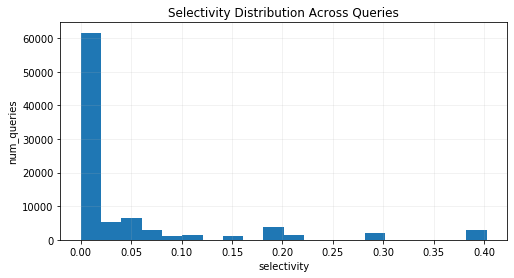

             bin  num_queries     ratio  hit_count_min  hit_count_max         hit_count_range  hit_count_sum
 (-0.001, 0.001]        19968  0.223789          100.0         7414.0         100.0 to 7414.0       63234458
  (0.001, 0.005]        15488  0.173580         7415.0        37068.0       7415.0 to 37068.0      298647322
   (0.005, 0.01]        12293  0.137772        37072.0        74096.0      37072.0 to 74096.0      664575844
    (0.01, 0.02]        13521  0.151535        74141.0       148278.0     74141.0 to 148278.0     1499006903
    (0.02, 0.05]         9892  0.110863       148283.0       370663.0    148283.0 to 370663.0     2645490455
     (0.05, 0.1]         5976  0.066975       370714.0       739231.0    370714.0 to 739231.0     2994951300
      (0.1, 0.2]         6025  0.067524       761360.0      1370392.0   761360.0 to 1370392.0     7139108661
      (0.2, 0.5]         6064  0.067961      1548549.0      2983813.0  1548549.0 to 2983813.0    14493656444
      (0.5, 1.0]   

In [9]:
# Distribution: histogram + bucket frequencies + hit_count ranges
s = selectivity_df['selectivity']

plt.figure(figsize=(8, 4))
plt.hist(s, bins=20)
plt.xlabel('selectivity')
plt.ylabel('num_queries')
plt.title('Selectivity Distribution Across Queries')
plt.grid(alpha=0.2)
plt.show()

bins = np.array([0.0, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0])
bin_cat = pd.cut(s, bins=bins, include_lowest=True)

dist_df = (
    selectivity_df
    .assign(bin=bin_cat)
    .groupby('bin')['hit_count']
    .agg(['count', 'min', 'max', 'sum'])
    .reset_index()
)

dist_df = dist_df.rename(columns={
    'count': 'num_queries',
    'min': 'hit_count_min',
    'max': 'hit_count_max',
    'sum': 'hit_count_sum'
})

dist_df['ratio'] = dist_df['num_queries'] / len(s)
dist_df['hit_count_range'] = dist_df['hit_count_min'].astype(str) + ' to ' + dist_df['hit_count_max'].astype(str)
dist_df['bin'] = dist_df['bin'].astype(str)

dist_df = dist_df[['bin', 'num_queries', 'ratio', 'hit_count_min', 'hit_count_max', 'hit_count_range', 'hit_count_sum']]
print(dist_df.to_string(index=False))

In [ ]:
# Save detailed results if needed
out_csv = Path('query_selectivity_summary.csv')
selectivity_df.to_csv(out_csv, index=False)
print('saved:', out_csv.resolve())

saved: /scratch1/zhan4404/dataset/caselaw/query_selectivity_summary.csv
